In [1]:
import numpy as np
import pickle
import pandas as pd
import yaml
import os
from matplotlib import pyplot as plt
import pysindy as ps
from hsa_hopper.collocation import interp_covector

def savgol(t,x,deg,window,ord=[0]):
    N = x.shape[0]
    outputs = np.zeros((N-window,len(ord)))
    for i in range(N-window):
        a = t[i]
        b = t[i+window]
        c = t[i+window//2]
        tensor = np.vstack([interp_covector(t[i+j],a,b,deg+1) for j in range(window)])
        coeffs = np.linalg.lstsq(tensor,x[i:i+window],rcond=None)[0]
        for j,o in enumerate(ord):
            tensor = interp_covector(c,a,b,deg+1,ord=o)[0]
            outputs[i,j] = np.dot(tensor,coeffs)
    return outputs

def smooth_dynamics(df, deg, window):
    new_df = pd.DataFrame(columns=df.columns)
    _t = df['t'].to_numpy()
    _t = _t - _t[0]
    new_df['t'] = _t[window//2:-window//2]
    _x = df['x'].to_numpy()
    outputs = savgol(_t,_x,deg,window,ord=[0,1,2])
    new_df['x'] = outputs[:,0]
    new_df['xdot'] = outputs[:,1]
    new_df['xddot'] = outputs[:,2]
    _tau = df['tau'].to_numpy()
    outputs = savgol(_t,_tau,deg,window)
    new_df['tau'] = outputs[:,0]
    return new_df


In [2]:
from hsa_hopper.kinematics import KinematicParameters, forward_kinematics
"""
Load all data from the HSA characterization dataset
"""
characterization = {
    'folder' : r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\hsa_identification\2024-06-13_1718318116'
}
characterization['data'] = []
characterization['hsa_angle'] = []
keep_columns = ['motor_angle', 'motor_torque', 'times']
columns = ['x','y','l','xdot','ydot','ldot','xddot','yddot','lddot','tau','t','psi','dydx', 'dldx', 'd2yd2x', 'd2ld2x', 'mode','m']

# dictionary for remapping column names
column_map = {
    'motor_angle': lambda motor_angle: ('x',motor_angle), 
    'motor_torque': lambda motor_torque: ('tau', motor_torque),
    'times' : lambda times: ('t', times),
}

with open(os.path.join(characterization['folder'], 'experiment_config.yaml'), 'r') as f:
    characterization['experiment_config'] = yaml.load(f, yaml.Loader)

with open(os.path.join(characterization['folder'], 'hardware_config.yaml'), 'r') as f:
    characterization['hardware_config'] = yaml.load(f, yaml.Loader)

deg = 2
window = 2*(deg+1) + 3 
with open(os.path.join(characterization['folder'], 'data.pickle'), 'rb') as f:
    all_data = pickle.load(f)
    for idx in range(len(all_data['motor_angle'])):
        # input_df = pd.DataFrame({key : all_data[key][idx] for key in keep_columns})
        input_df = pd.DataFrame(columns=columns)
        data_remapped = {}
        for key, map in column_map.items():
            new_key, new_data = map(all_data[key][idx])
            input_df[new_key] = new_data
        smoothed_df = smooth_dynamics(input_df, deg, window)
        x = smoothed_df['x'].to_numpy()
        hardware_config = characterization['hardware_config']
        kin_params = KinematicParameters(**hardware_config['kinematics'])
        FK = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
        smoothed_df['y'] = FK[0][0]
        smoothed_df['l'] = FK[0][1]
        smoothed_df['dydx'] = FK[1][0]
        smoothed_df['dldx'] = FK[1][1]
        smoothed_df['d2yd2x'] = FK[2][0]
        smoothed_df['d2ld2x'] = FK[2][1]
        smoothed_df['psi'] = (np.pi/180)*all_data['hsa_angle'][idx]*np.ones(len(smoothed_df))
        smoothed_df['mode'] = np.zeros(len(smoothed_df))
        smoothed_df['m'] = np.zeros(len(smoothed_df))
        characterization['data'].append(smoothed_df)

In [3]:
"""
Load all data from a hopping experiment.
"""

# constants for converting servo pulse to angle
_MIN_PULSE = 500
_MAX_PULSE = 2500
_ZERO_SETPOINT = 1500
_ANGLE_RANGE = 1800
def pulse_to_angle(pulse, gear_ratio):
    return (_ANGLE_RANGE / (_MAX_PULSE-_MIN_PULSE)) * gear_ratio * (pulse - _ZERO_SETPOINT)

# remapping data frame columns to match characterization data
column_map = {
    'x_deg': lambda x_deg: ('x',x_deg*np.pi/180), 
    # 'torque': lambda torque: ('tau', torque),
    'u_ff': lambda torque: ('tau', torque),
    't_s' : lambda t_s: ('t', t_s),
    'mode': lambda mode: ('mode', mode)
}

hop_experiment_dir = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\hsa_hopper_data_06_13_2024\hop_experiments\hsa'
hopping = {'data': [], 'experiment_config': [], 'hardware_config': [], 'energy': []}

# order = 2
# decimate = 5
deg = 2
window = 2*(deg+1) + 3
for folder in os.listdir(hop_experiment_dir):
    path = os.path.join(hop_experiment_dir, folder)
    with open(os.path.join(path, 'experiment_config.yaml'), 'r') as f:
        hopping['experiment_config'].append(yaml.load(f,yaml.Loader))
    with open(os.path.join(path, 'hardware_config.yaml'), 'r') as f:
        hopping['hardware_config'].append(yaml.load(f,yaml.Loader))
    hopping['energy'].append(pd.read_csv(os.path.join(path,'energy.csv')))
    hop_files = []
    for filename in os.listdir(path):
        if filename[:3] == 'hop':
            idx = int(filename.split('_')[1].split('.')[0])
            hop_files.append((idx, filename))
    hop_files = sorted(hop_files, key = lambda args: args[0])
    dataframes = []
    for idx, filename in hop_files:
        input_df = pd.read_csv(os.path.join(path, filename))
        output_df = pd.DataFrame(columns=columns)
        for key, map in column_map.items():
            new_key, new_data = map(input_df[key].to_numpy())
            output_df[new_key] = new_data
        # output_df = pd.DataFrame(output_df[output_df['mode']==2])
        # output_df = output_df[output_df['mode']==2]
        smoothed_df = smooth_dynamics(output_df, deg, window)

        # unpacking experiment parameters
        experiment_config = hopping['experiment_config'][-1]
        hardware_config = hopping['hardware_config'][-1]
        kin_params = KinematicParameters(**hardware_config['kinematics'])
        mass = experiment_config['dynamics_params']['m']
        pulse = experiment_config['controller']['servo_pos']
        gear_ratio = hardware_config['servo']['gear_ratio']
        psi_deg = pulse_to_angle(pulse, gear_ratio)

        # evaluate FK
        x = smoothed_df['x'].to_numpy()
        FK = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
        smoothed_df['y'] = FK[0][0]
        smoothed_df['l'] = FK[0][1]
        smoothed_df['dydx'] = FK[1][0]
        smoothed_df['dldx'] = FK[1][1]
        smoothed_df['d2yd2x'] = FK[2][0]
        smoothed_df['d2ld2x'] = FK[2][1]
        smoothed_df['psi'] = (np.pi/180)*psi_deg*np.ones(len(smoothed_df))
        smoothed_df['m'] = mass*np.ones(len(smoothed_df))
        smoothed_df['mode'] = output_df['mode'].to_numpy()[window//2:-window//2]
        # dataframes.append(smoothed_df) 
        dataframes.append(smoothed_df[smoothed_df['mode']==2]) 
    hopping['data'].append(dataframes)

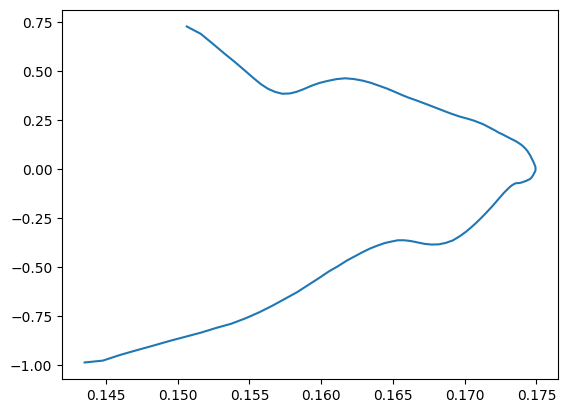

In [4]:
df = hopping['data'][3][6]
plt.plot(df['l'],df['xdot']*df['dldx'])

In [5]:
from numpy.random import default_rng
N_CHAR_ROWS = sum(len(df) for df in characterization['data'])
N_HOP_ROWS = sum(len(df) for trial in hopping['data'] for df in trial)
ALL_DATA = np.vstack([df.to_numpy() for df in characterization['data']]+[df.to_numpy() for trial in hopping['data'] for df in trial])
CHAR_ROW_INDICES = range(N_CHAR_ROWS)
HOP_ROW_INDICES = range(N_CHAR_ROWS,N_CHAR_ROWS+N_HOP_ROWS)

rng = default_rng()
CHAR_TRAIN_INDICES = rng.choice(CHAR_ROW_INDICES, 50*N_CHAR_ROWS//100, replace=False)
HOP_TRAIN_INDICES = rng.choice(HOP_ROW_INDICES, 50*N_HOP_ROWS//100, replace=False)
TRAIN_INDICES = list(CHAR_TRAIN_INDICES) + list(HOP_TRAIN_INDICES)
# TRAIN_INDICES = list(CHAR_TRAIN_INDICES)
# TRAIN_INDICES = list(HOP_TRAIN_INDICES)
DATA_COLUMN_MAP = {columns[i] : i for i in range(len(columns))}
UNIQUE_PSI = np.sort(np.unique(ALL_DATA[TRAIN_INDICES,DATA_COLUMN_MAP['psi']]))

In [6]:
print(len(TRAIN_INDICES))

30904


In [7]:
from hsa_hopper.hsa_model import HSAModel, LinearModel
def make_lstsq_data(model, row_indices):
    N = model.num_params()
    M = len(row_indices)
    A = np.zeros((M,3+N))
    b = np.zeros(M)
    for i, idx in enumerate(row_indices):
        x = ALL_DATA[idx,DATA_COLUMN_MAP['x']]
        y = ALL_DATA[idx,DATA_COLUMN_MAP['y']]
        l = ALL_DATA[idx,DATA_COLUMN_MAP['l']]
        xdot = ALL_DATA[idx,DATA_COLUMN_MAP['xdot']]
        xddot = ALL_DATA[idx,DATA_COLUMN_MAP['xddot']]
        tau = ALL_DATA[idx,DATA_COLUMN_MAP['tau']]
        dydx = ALL_DATA[idx,DATA_COLUMN_MAP['dydx']]
        dldx = ALL_DATA[idx,DATA_COLUMN_MAP['dldx']]
        d2yd2x = ALL_DATA[idx,DATA_COLUMN_MAP['d2yd2x']]
        d2ld2x = ALL_DATA[idx,DATA_COLUMN_MAP['d2ld2x']]
        psi = ALL_DATA[idx,DATA_COLUMN_MAP['psi']]
        mode = ALL_DATA[idx,DATA_COLUMN_MAP['mode']]
        m = ALL_DATA[idx,DATA_COLUMN_MAP['m']]
        ydot = dydx*xdot
        ldot = dldx*xdot
        if mode == 0:
            b[i] = tau
            A[i,0] = xddot*dldx**2 + ldot*d2ld2x*xdot
            # A[i,0] = 0
            A[i,2] = 0
        elif mode == 2:
            # b[i] = tau - dydx*m*9.81 - m*xddot*dydx**2 - m*ydot*d2yd2x*xdot
            b[i] = tau - dydx*m*9.81  - m*ydot*d2yd2x*xdot
            # b[i] = tau - dydx*m*9.81 - m*xddot*dydx**2
            # b[i] = tau - dydx*m*9.81
            # A[i,0] = -dydx*9.81
            A[i,2] = xdot
            A[i,0] = 0
        A[i,1] = xddot
        z = np.array([l,psi])
        zdot = np.array([ldot,0])
        if model.linear is None:
            N_c = model.w_c.shape[0]
            N_d = model.w_d.shape[0]
            for j in range(N_c):
                A[i,3+j] = dldx*model.dkc(z,j)[0]
            for j in range(N_d):
                A[i,3+N_c+j] = dldx*model.dkd(z,zdot,j)[0]
        else:
            A[i,3] = dldx*l
            A[i,4] = dldx
            A[i,5] = dldx*ldot
            N_c = model.w_c.shape[0]
            N_d = model.w_d.shape[0]
            for j in range(N_c):
                A[i,6+j] = dldx*model.dkc(z,j)[0]
            for j in range(N_d):
                A[i,6+N_c+j] = dldx*model.dkd(z,zdot,j)[0]
    return A,b

In [8]:
"""
Experimental - fitting two potential functions and blending them together with a logistic function
"""

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint
from hsa_hopper.hsa_model import HSAModel

# function to do the model optimization
def governing_equation_lstsq(model):
    N = model.num_params()
    A,b = make_lstsq_data(model,TRAIN_INDICES)

    # rescaling A matrix for better conditioning of constraint evaluation
    SCALE = np.ones(A.shape[1])
    SCALE[0] = 1/10 # leg mass rescaling
    SCALE[1] = 1/1000 # motor inertia rescaling
    SCALE[2] = 1/1000 # motor damping rescaling

    A_scaled = A*SCALE
    ATA = A_scaled.T@A_scaled
    ATb = A_scaled.T@b
    bTb = np.dot(b,b)
    f = lambda x: x.T@ATA@x+bTb-2*x.T@ATb
    jac = lambda x: 2*ATA@x-2*ATb
    # hess = lambda x: 2*ATA

    lb = np.array([0,1,1])
    ub = np.array([5,10,150])
    C = np.eye(A.shape[1])
    if model.linear is not None:
        lb = np.hstack((lb,np.array([0,-1000,0])))
        ub = np.hstack((ub,np.array([2000,1000,50])))
    lb = np.hstack((lb, -100*np.ones(model.w_c.shape[0]), -100*np.ones(model.w_d.shape[0])))
    ub = np.hstack((ub, 100*np.ones(model.w_c.shape[0]), 100*np.ones(model.w_d.shape[0])))
    constraints = [LinearConstraint(C,lb=lb,ub=ub)]

    x0 = (lb+ub)/2
    result = minimize(f, x0, 
                    jac=jac, 
                    constraints=constraints, 
                    method='SLSQP',
                    options={'maxiter' : 10000}
    )
    result.A = A
    result.b = b
    result.sample_size = b.shape[0]
    result.num_params = model.num_params()
    result.m_l = result.x[0]*SCALE[0]
    result.J_x = result.x[1]*SCALE[1]
    result.b_x = result.x[2]*SCALE[2]
    offset = 3
    if model.linear is not None:
        model.linear.k = result.x[offset+0]
        model.linear.f = result.x[offset+1]
        model.linear.b = result.x[offset+2]
        offset += 3
    N_c = model.w_c.shape[0]
    model.w_c = result.x[offset:offset+N_c]
    model.w_d = result.x[offset+N_c:]
    result.model = model
    result.r_sqr = 1-result.fun/np.sum((b-np.average(b))**2)
    result.r_sqr_adj = 1-(1-result.r_sqr)*(result.sample_size-1)/(result.sample_size-result.num_params-1)
    result.mse = result.fun/result.sample_size
    result.rmse = np.sqrt(result.mse)
    result.bic = result.sample_size*np.log(result.mse)+result.num_params*np.log(result.sample_size)
    result.errors = A@(SCALE*result.x)-b
    return result 
    

In [23]:
linear_model = LinearModel(0,0,0)
y_c = y_d = np.zeros((0,0))
w_c = w_d = np.zeros(0)
model = HSAModel(w_c,y_c,w_d,y_d,1,1,linear_model)
linear_result = governing_equation_lstsq(model)
print(linear_result)
print(linear_result.model.linear.attribute_dict())

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 15343.268780733546
           x: [ 1.788e+00  5.529e+00  1.294e+02  7.820e+02 -1.134e+02
                1.827e+01]
         nit: 13
         jac: [-5.840e-05 -7.470e-04 -3.358e-06 -1.229e-05  2.911e-05
                9.263e-05]
        nfev: 18
        njev: 13
           A: [[-7.135e-01 -1.166e+02 ...  7.600e-02  3.110e-02]
               [-3.253e-01 -4.464e+01 ...  7.368e-02 -3.448e-02]
               ...
               [ 0.000e+00 -1.910e+02 ...  7.373e-02 -3.029e-02]
               [ 0.000e+00 -1.158e+02 ...  7.140e-02  2.074e-02]]
           b: [ 7.787e-01  1.789e-01 ... -2.598e+00  1.217e+00]
 sample_size: 30904
  num_params: 3
         m_l: 0.17881393819955807
         J_x: 0.005529004619738355
         b_x: 0.12939329377650707
       model: <hsa_hopper.hsa_model.HSAModel object at 0x000001731EA359D0>
       r_sqr: 0.8103471847846253
   r_sqr_adj: 0.8103287718899442
         mse

In [97]:
from scipy.optimize import minimize_scalar
generalized = []
M_values = [(8,6,3)]
for i,M in enumerate(M_values):
    print(M)
    l_min = min(ALL_DATA[TRAIN_INDICES,DATA_COLUMN_MAP['l']])
    l_max = max(ALL_DATA[TRAIN_INDICES,DATA_COLUMN_MAP['l']])
    PSI_TRAIN = np.linspace(np.min(UNIQUE_PSI),np.max(UNIQUE_PSI),M[2])

    if M[0] > 0:
        y_c = np.zeros((2,M[0]*M[2]))
    else:
        y_c = np.zeros((0,0))
    if M[1] > 0:
        y_d = np.zeros((2,M[1]*M[2]))
    else:
        y_d = np.zeros((0,0))

    l_values = np.linspace(l_min,l_max,M[0])
    for i in range(M[0]):
        for j in range(M[2]):
            y_c[0,i+M[0]*j] = l_values[i]
            y_c[1,i+M[0]*j] = PSI_TRAIN[j]

    l_values = np.linspace(l_min,l_max,M[1])
    for i in range(M[1]):
        for j in range(M[2]):
            y_d[0,i+M[1]*j] = l_values[i]
            y_d[1,i+M[1]*j] = PSI_TRAIN[j]
    w_c = np.zeros(y_c.shape[1])
    w_d = np.zeros(y_d.shape[1])
    make_model = lambda s: HSAModel(w_c,y_c,w_d,y_d,1e-2,s,linear=LinearModel(0,0,0),kind=HSAModel.QUADRATIC)
    result = governing_equation_lstsq(make_model(np.sqrt(2)))
    generalized.append(result)
    print(result.r_sqr)
    print(result.message)

(8, 6, 3)
0.9227965330838469
Optimization terminated successfully


In [98]:
print(generalized[-1])
print(generalized[-1].rmse/linear_result.rmse)
print(generalized[-1].model.w_c)
print(generalized[-1].model.w_d)
print(generalized[-1].model.linear.attribute_dict())

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 6245.905405378755
           x: [ 2.860e-15  3.403e+00 ...  2.971e-01  3.365e-01]
         nit: 65
         jac: [ 4.111e+00 -6.550e-06 ...  7.821e-04  1.183e-04]
        nfev: 176
        njev: 65
           A: [[-7.135e-01 -1.166e+02 ...  5.035e-04  1.193e-04]
               [-3.253e-01 -4.464e+01 ... -1.076e-03 -4.109e-04]
               ...
               [ 0.000e+00 -1.910e+02 ... -2.759e-02 -1.114e-02]
               [ 0.000e+00 -1.158e+02 ...  1.049e-02  6.004e-03]]
           b: [ 7.787e-01  1.789e-01 ... -2.598e+00  1.217e+00]
 sample_size: 30904
  num_params: 45
         m_l: 2.8600094461962452e-16
         J_x: 0.003402958114022741
         b_x: 0.1265705079734857
       model: <hsa_hopper.hsa_model.HSAModel object at 0x0000017322AB7010>
       r_sqr: 0.9227965330838469
   r_sqr_adj: 0.9226839478219626
         mse: 0.20210669833609743
        rmse: 0.4495627857553352
        

In [99]:
model = generalized[-1].model
print(model.Sd)
print(np.sqrt(model.sd))
print([model.dkd(model.y_d[:,0], np.array([1,0]), i) for i in range(model.w_d.shape[0])])
# print([model.dkc(model.y_c[:,i], i) for i in range(model.w_c.shape[0])])

[[ 6.35759139e-04 -1.42872648e-19]
 [-1.42872648e-19  9.79703378e-01]]
0.024957070672652962
[array([4.94817182e+02, 7.21604545e-17]), array([3.13015448e+02, 4.56478430e-17]), array([7.92371365e+01, 1.15553542e-17]), array([8.02663978e+00, 1.17054540e-18]), array([3.25372448e-01, 4.74498959e-20]), array([5.27800475e-03, 7.69704926e-22]), array([6.67343058e+01, 9.73203442e-18]), array([4.22153260e+01, 6.15636891e-18]), array([1.06864424e+01, 1.55843121e-18]), array([1.08252553e+00, 1.57867466e-19]), array([4.38818725e-02, 6.39940564e-21]), array([7.11826501e-04, 1.03807478e-22]), array([1.63705125e-01, 2.38735368e-20]), array([1.03557910e-01, 1.51021147e-20]), array([2.62147835e-02, 3.82296890e-21]), array([2.65553040e-03, 3.87262787e-22]), array([1.07646095e-04, 1.56983052e-23]), array([1.74617305e-06, 2.54648880e-25])]


In [100]:
model = generalized[-1].model
print([(model.w_d[i],model.y_d[:,i]) for i in range(model.w_d.shape[0]) if abs(model.w_d[i])>1e-3])

[(4.133516709739276, array([ 0.11173176, -1.57079633])), (-3.9724233136968974, array([ 0.12607975, -1.57079633])), (2.8044343798975593, array([ 0.14042774, -1.57079633])), (-1.5568766388376296, array([ 0.15477573, -1.57079633])), (0.5086024667772566, array([ 0.16912372, -1.57079633])), (0.5854766089413422, array([ 0.18347172, -1.57079633])), (0.879263520465705, array([ 0.11173176, -0.39269908])), (-1.0738531707361891, array([ 0.12607975, -0.39269908])), (0.9995491778835996, array([ 0.14042774, -0.39269908])), (-0.8961290635740244, array([ 0.15477573, -0.39269908])), (0.8618666652813171, array([ 0.16912372, -0.39269908])), (-0.7274951762216005, array([ 0.18347172, -0.39269908])), (0.6585468129090556, array([0.11173176, 0.78539816])), (-0.6343876902777956, array([0.12607975, 0.78539816])), (0.628590899359051, array([0.14042774, 0.78539816])), (-0.5922854665166611, array([0.15477573, 0.78539816])), (0.2970582037799321, array([0.16912372, 0.78539816])), (0.3365347337973128, array([0.183471

In [101]:
# fit chi-squared distributions to models, packall information into dataframe for plotting
import pandas as pd
data_frame = pd.DataFrame(columns=['SOS','RSQR','RSQR_ADJ','RMSE','N', 'M', 'BIC','a','kind'])
rows = []
# for result in classical_damping:
    # errors = result.errors
    # rows.append({
    #     'SOS' : result.fun,
    #     'RSQR' : result.r_sqr,
    #     'RSQR_ADJ' : result.r_sqr_adj,
    #     'RMSE' : result.rmse,
    #     'N' : result.num_params,
    #     'BIC' : result.bic,
    #     'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
    #     'kind' : 'classical damping'
    # })
# for result in classical_spring:
#     errors = result.errors
#     rows.append({
#         'SOS' : result.fun,
#         'RSQR' : result.r_sqr,
#         'RSQR_ADJ' : result.r_sqr_adj,
#         'RMSE' : result.rmse,
#         'N' : result.num_params,
#         'BIC' : result.bic,
#         'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
#         'kind' : 'classical spring'
#     })
for result in generalized:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        'kind' : 'generalized'
    })

total_df= pd.DataFrame(rows)


In [102]:
# configure matplotlib rcparams for style
import matplotlib.pyplot as plt
from cycler import cycler

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Define a custom color cycle of 10 colors
colorblind_friendly_colors = ['#6a0dad', '#2ca02c', '#e2a000', '#1f77b4', '#ff7f0e', '#d62728']

# Update the default color cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colorblind_friendly_colors)

In [103]:
print(os.listdir(hop_experiment_dir))

['hsa_wood_1300g', 'hsa_wood_1500g', 'hsa_wood_1700g', 'hsa_wood_1900g', 'hsa_wood_2100g', 'hsa_wood_2300g']


In [104]:
"""
Compare hopping trajectories to the prediction from forward simulation
"""
from hsa_hopper import dynamics

# integration step
def step(x,xdot,u,params,dt):
    a = dynamics.evaluate(x,xdot,u,params)
    return x+dt*xdot+.5*a*dt**2, xdot + dt*a 

# forward simulation loop
def forward_sim(x0,xdot0,ufunc,params,tvec):
    x = np.zeros(N_timesteps)
    x[0] = x0
    xdot = np.zeros(N_timesteps)
    xdot[0] = xdot0
    # t = np.linspace(t0,tf,N_timesteps)
    for i in range(tvec.shape[0]-1):
        _x, _xdot = step(x[i],xdot[i],ufunc(tvec[i]),params,tvec[i+1]-tvec[i])
        x[i+1] = _x
        xdot[i+1] = _xdot
    return x,xdot

# select hopping trial to examine
idx = 3
experiment_config = hopping['experiment_config'][idx]
hardware_config = hopping['hardware_config'][idx]
kin_params = KinematicParameters(**hardware_config['kinematics'])
mass = experiment_config['dynamics_params']['m']
pulse = experiment_config['controller']['servo_pos']
gear_ratio = hardware_config['servo']['gear_ratio']
psi_deg = pulse_to_angle(pulse, gear_ratio)

# select HSA model for params
generalized_result = generalized[-1]
generalized_params = dynamics.DynamicsParameters(
    mass,
    generalized_result.J_x,
    generalized_result.b_x,
    0, # by
    0, # kx
    0, # x0
    kin_params,
    hsa_model=generalized_result.model,
    psi=psi_deg*np.pi/180
)

# construct interpolation function
from hsa_hopper import collocation
u_coeffs = np.array(hopping['experiment_config'][idx]['controller']['u_interp'][2]['mat'])[0]
u_tk = np.array(hopping['experiment_config'][idx]['controller']['u_interp'][2]['tk'])
covec = lambda t: collocation.interp_covector(t,u_tk[0],u_tk[1],len(u_coeffs))[0]

t_generalized_sim = []
x_generalized_sim = []
y_generalized_sim = []
t_emp = []
x_emp = []
y_emp = []
y_errors = []

for idx,df in enumerate(hopping['data'][idx]):
    row = df.iloc[0,:]
    ufunc = lambda t: np.dot(covec(t),u_coeffs)
    t_emp.append(df['t'].to_numpy())
    t_emp[-1] = t_emp[-1]-t_emp[-1][0]
    x_emp.append(df['x'].to_numpy())
    xdot_emp = df['xdot'].to_numpy()
    x0 = x_emp[-1][0]
    xdot0 = xdot_emp[0]
    N_timesteps = t_emp[idx].shape[0]
    x_sim, xdot_sim = forward_sim(x0,xdot0,ufunc,generalized_params,t_emp[-1])
    y_sim = forward_kinematics(generalized_params.kinematics, x_sim)[1]
    x_generalized_sim.append(x_sim)
    y_generalized_sim.append(y_sim)
    y_emp.append(forward_kinematics(generalized_params.kinematics, x_emp[-1])[1])
    y_errors.append(y_generalized_sim[-1]-y_emp[-1])

0.01570765719264987


Text(0.5, 1.0, 'Body Displacement Prediction Error During Hopping')

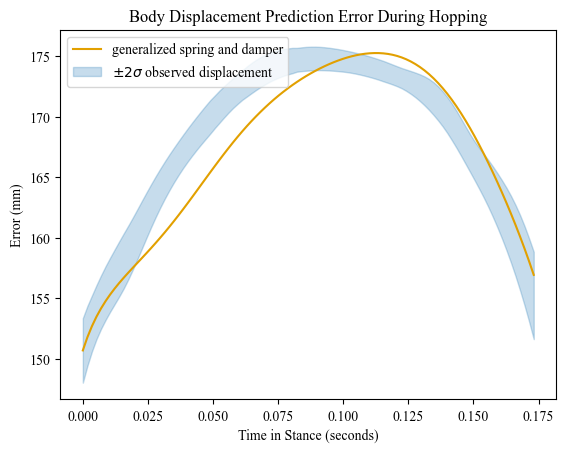

In [105]:
tf_min = np.min([t[-1] for t in t_emp])
t_linspace = np.linspace(0,tf_min,100)
y_generalized_interp = np.array([np.interp(t_linspace, t_emp[i], y_generalized_sim[i]) for i in range(len(y_generalized_sim))])
y_emp_interp = np.array([np.interp(t_linspace, t_emp[i], y_emp[i]) for i in range(len(x_emp))])

y_generalized_mean = np.mean(y_generalized_interp-y_emp_interp, axis=0)
# y_classical_spring_mean = np.mean(y_classical_spring_interp-y_emp_interp, axis=0)
y_emp_mean = np.mean(y_emp_interp, axis=0)
y_emp_std = np.std(y_emp_interp, axis=0)
y_errors = np.hstack(y_errors)
print(np.sqrt(np.mean(y_errors**2))/np.mean(np.hstack(y_sim)))
plt.plot(t_linspace, 1000*(y_emp_mean+y_generalized_mean), color='C2', label='generalized spring and damper')
plt.fill_between(t_linspace, 1000*(y_emp_mean+2*y_emp_std), 1000*(y_emp_mean-2*y_emp_std), color='C3', alpha=.25, label=r'$\pm 2\sigma$ observed displacement')
plt.legend(loc='upper left')
plt.xlabel('Time in Stance (seconds)')
plt.ylabel('Error (mm)')
plt.title('Body Displacement Prediction Error During Hopping')


Text(0.5, 1.1, 'HSA Model Performance Comparison')

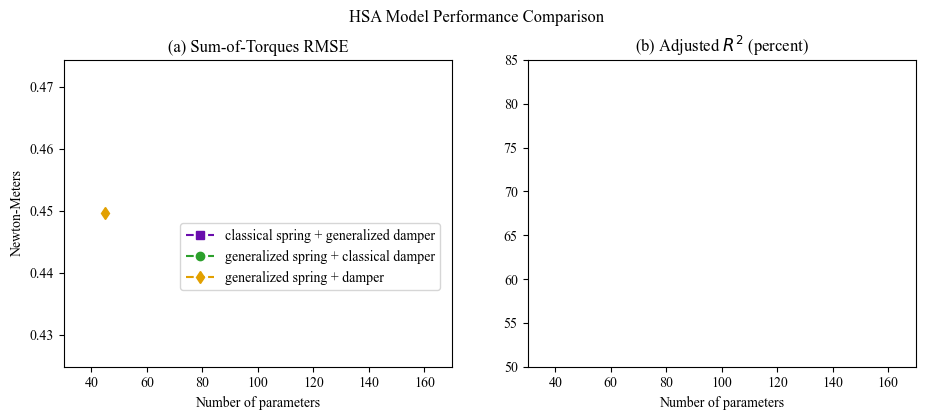

In [106]:
# RMSE / Adjusted R^2 plot combined
fig, axs = plt.subplots(1,2,sharex=True)
fig.tight_layout()
fig.set_figheight(3.5)
fig.set_figwidth(9.5)
sub_df = total_df[total_df['kind'] == 'classical spring']
N1 = sub_df['N'].to_numpy()
y1 = sub_df['RMSE'].to_numpy()
axs[0].plot(N1, y1, label='classical spring + generalized damper',marker='s', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'classical damping']
N2 = sub_df['N'].to_numpy()
y2 = sub_df['RMSE'].to_numpy()
axs[0].plot(N2, y2, label='generalized spring + classical damper',marker='o', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'generalized']
N3 = sub_df['N'].to_numpy()
y3 = sub_df['RMSE'].to_numpy()
axs[0].plot(N3, y3, label='generalized spring + damper',marker='d', linestyle='dashed')

axs[0].set_xlim(15,120)
axs[0].set_xlabel('Number of parameters')
axs[0].set_ylabel('Newton-Meters')
axs[0].set_title('(a) Sum-of-Torques RMSE')
axs[0].legend(loc=(.3,.25))

sub_df = total_df[total_df['kind'] == 'classical spring']
N1 = sub_df['N'].to_numpy()
y1 = sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N1, 100*y1, label='classical spring + generalized damper',marker='s', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'classical damping']
N2 = sub_df['N'].to_numpy()
y2 = sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N2, 100*y2, label='generalized spring + classical damper',marker='o', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'generalized']
N3 = sub_df['N'].to_numpy()
y3 = sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N3, 100*y3, label='generalized spring + damper',marker='d', linestyle='dashed')

axs[1].set_xlim(30,170)
axs[1].set_ylim(50,85)
# axs[1].legend()
axs[1].set_xlabel('Number of parameters')
axs[1].set_title(r'(b) Adjusted $R^2$ (percent)')
fig.suptitle('HSA Model Performance Comparison',x=.5,y=1.1)

0.0


Text(0, 0.5, 'Damping Force (N)')

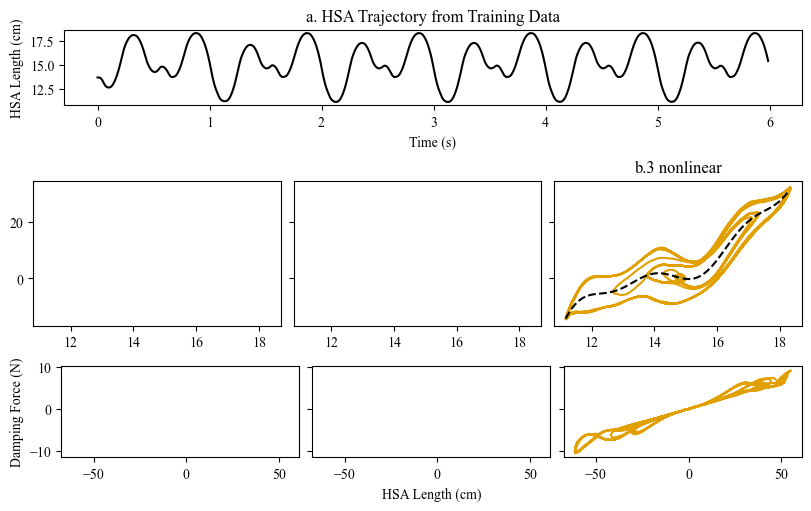

In [107]:
# plot to compare Force/Length for different values of psi under the chosen model (nonlinear, M=6)
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
supfig = plt.figure(layout='constrained', figsize=(8,5))
figs = supfig.subfigures(nrows=3,ncols=1,height_ratios=([.3,.4,.3]))

# get data from HSA characterization
decimate = 2
hop_idx = 0
char_idx = 2
# df = hopping['data'][hop_idx][5]
df = characterization['data'][char_idx]
psi = df['psi'].to_numpy()[0]-0*np.pi/180
print(psi*180/np.pi)
l = df['l'].to_numpy()[::decimate]
xdot = df['xdot'].to_numpy()[::decimate]
dldx = df['dldx'].to_numpy()[::decimate]
ldot = dldx*xdot
t = df['t'].to_numpy()[::decimate]
l_min = np.min(l)
l_max = np.max(l)
l_linspace = np.arange(l_min, l_max, .001)
model3 = generalized[-1].model

# plot trajectory of training data
axstop = figs[0].subplots()
axstop.plot(t-t[0],100*l,color='black')
# axstop.plot(t[i][1:-1]-t[i][0],100*ldot,color='black')
axstop.set_xlabel('Time (s)')
axstop.set_ylabel('HSA Length (cm)')
axstop.set_title('a. HSA Trajectory from Training Data')

# calculate elastic force and plot in 1x3 subfig with sharex and sharey
axsmid = figs[1].subplots(1,3,sharex=True,sharey=True)

elastic_force3 = np.array([model3.dV([l[i],psi]) for i in range(len(l))])
damp_force3 = np.array([model3.dR([l[i],psi],np.array([ldot[i],0])) for i in range(len(l))])
elastic_force_dashed3 = np.array([model3.dV([_l,psi]) for _l in l_linspace])
axsmid[2].plot(100*l,elastic_force3+damp_force3,color='C2')
axsmid[2].plot(100*l_linspace,elastic_force_dashed3,color='black', linestyle='dashed')
axsmid[2].set_title('b.3 nonlinear')
# axsmid[0].set_ylim(-30,50)
# axsmid[0].set_yticks([-25,0,25,50])
# axsmid[0].set_ylabel('Total Force (N)')
# axsmid[0].set_xticks([12,15,18])
# axsmid[0].set_xlim((11,18.5))

# now damping force plots
axsbot = figs[2].subplots(1,3,sharex=True,sharey=True)
axsbot[2].plot(100*ldot,damp_force3,color='C2')
axsbot[1].set_xlabel('HSA Length (cm)')
axsbot[0].set_ylabel('Damping Force (N)')
# axsbot[0].set_ylim(-10,10)
# axsbot[0].set_xticks([12,15,18])
# axsbot[0].set_xlim((11,18.5))


In [108]:
print(ldot)

[ 2.70155175e-05 -2.65971910e-04 -2.58962873e-03 ... -5.21408015e-01
 -5.36286356e-01 -5.43680427e-01]


In [109]:
from hsa_hopper.collocation import *
boundary_cond = experiment_config['stance_boundary_cond']
controller = experiment_config['controller']
data = hopping['data'][idx][10]

# extract feed-forward control interpolation
u_interp = PiecewiseInterpolation.make_from_dict(controller['u_interp'][-1])
u_coeffs = u_interp.mat
tk = u_interp.tk
collo_params = CollocationParameters(1,5,4,tk[0],tk[1])

# fit interpolation to empirical x-values
tvec = np.linspace(tk[0],tk[1],collo_params.Nx)
t = data['t'].to_numpy()
x = data['x'].to_numpy()
x_interp = fit_interpolation(np.interp(tvec, t-t[0], x), np.zeros(collo_params.Nx), tvec, collo_params)[0]

""" Assemble boundary value problem """
# boundary conditions
init_cond = np.array([boundary_cond['x1'], boundary_cond['xdot1']])
final_cond = np.array([boundary_cond['xN'], boundary_cond['xdotN']])
lb = np.array([-50*np.pi/180,-20]) # lower bounds on motor angle and torque
ub = np.array([20*np.pi/180,20]) # upper bounds on motor angle and torque
bvp = HopBVP(init_cond,final_cond,lb,ub,generalized_params,collo_params)
z = np.hstack((x_interp.mat[0],u_interp.mat[0]))
# bvp.optimize(regeneration=False)
result = bvp.optimize(z,regeneration=False)

IndexError: list index out of range

In [ ]:
target_height = boundary_cond['ydotN']**2 / (2*9.81)
print(result.fun/target_height)
# print(bvp.cost_noregen(z)[0]/target_height)
# print(target_height)
# print(empirical_height)

16.724286858556557
